# Feature EDA — NVIDIA Developer Journey
Primary table: `dev_profile_final_v3` (9.38M developers)

**Key context:** 78% of developers are Unactivated (never crossed the activation gate). Most features are zero or null for this group. Sections that analyze behavioral features filter to the activated population unless stated otherwise.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

T = 'dev_profile_final_v3'
con = duckdb.connect('developer_project.duckdb', read_only=True)

schema = con.execute(f'DESCRIBE {T}').fetchdf()
all_cols = schema['column_name'].tolist()
total = con.execute(f'SELECT COUNT(*) FROM {T}').fetchone()[0]
print(f'{T}: {len(all_cols)} columns, {total:,} developers')
display(schema[['column_name', 'column_type']])

dev_profile_final_v3: 34 columns, 9,381,508 developers


,column_name,column_type
0,developer_id,VARCHAR
1,persona,VARCHAR
2,persona_confidence,DOUBLE
3,persona_confidence_tier,VARCHAR
4,mixed_persona_flag,INTEGER
5,current_journey_state_30d,VARCHAR
6,current_journey_state_confidence,DOUBLE
7,recent_journey_state_90d,VARCHAR
8,historical_journey_state_180d,VARCHAR
9,transition_90d_to_30d,VARCHAR


## 1. Population Overview — The Big Picture
Understanding the activation/dormancy split is essential context for every other section.

Total:        9,381,508
Activated:    2,052,459  (21.9%)
Unactivated:  7,329,049  (78.1%)


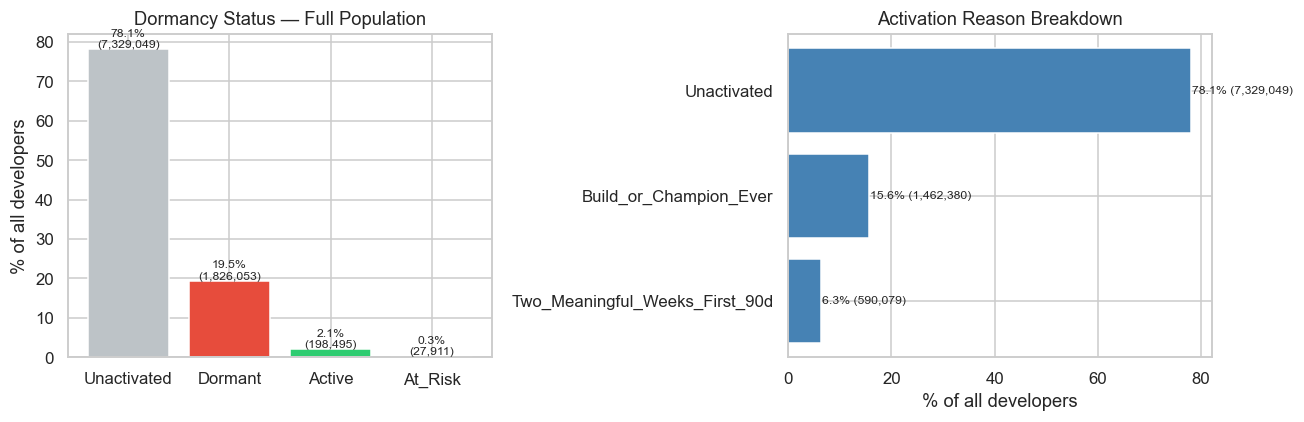

In [3]:
dormancy = con.execute(f"""
    SELECT dormancy_status,
           COUNT(*) AS developers,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()

activation = con.execute(f"""
    SELECT is_activated,
           COUNT(*) AS developers,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM {T} GROUP BY 1 ORDER BY 1 DESC
""").fetchdf()

n_activated = int(con.execute(f'SELECT SUM(is_activated) FROM {T}').fetchone()[0])
n_unactivated = total - n_activated
print(f'Total:       {total:>10,}')
print(f'Activated:   {n_activated:>10,}  ({n_activated/total*100:.1f}%)')
print(f'Unactivated: {n_unactivated:>10,}  ({n_unactivated/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dormancy status
colors = {'Active': '#2ecc71', 'At_Risk': '#f39c12', 'Dormant': '#e74c3c', 'Unactivated': '#bdc3c7'}
bar_colors = [colors.get(s, 'steelblue') for s in dormancy['dormancy_status']]
bars = axes[0].bar(dormancy['dormancy_status'], dormancy['pct'], color=bar_colors)
axes[0].set_ylabel('% of all developers')
axes[0].set_title('Dormancy Status — Full Population')
for bar, (_, row) in zip(bars, dormancy.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['pct']:.1f}%\n({row['developers']:,})", ha='center', fontsize=8)

# Activation reasons
act_reason = con.execute(f"""
    SELECT activation_reason, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()
axes[1].barh(act_reason['activation_reason'][::-1], act_reason['pct'][::-1], color='steelblue')
axes[1].set_xlabel('% of all developers')
axes[1].set_title('Activation Reason Breakdown')
for i, (_, row) in enumerate(act_reason[::-1].iterrows()):
    axes[1].text(row['pct'] + 0.2, i, f"{row['pct']:.1f}% ({row['developers']:,})", va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 2. Missingness — What's Missing and Why

In [4]:
null_exprs = ', '.join(f'SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS "{c}"' for c in all_cols)
null_counts = con.execute(f'SELECT {null_exprs} FROM {T}').fetchdf()

missingness = pd.DataFrame({
    'column': all_cols,
    'null_count': null_counts.values[0].astype(int),
    'null_pct': null_counts.values[0] / total * 100
}).sort_values('null_pct', ascending=False)

# Annotate known explanations
notes = {
    'days_since_last_activity': 'NULL = no activity in 30d window (all Unactivated + most Dormant)',
    'days_since_last_meaningful_week': 'NULL = Unactivated developers (78.1% of population)',
    'last_meaningful_week_start': 'NULL = Unactivated (no meaningful week ever recorded)',
    'lifetime_first_activity_date': 'NULL = developer has zero lifetime activity',
    'lifetime_last_activity_date': 'NULL = developer has zero lifetime activity',
}
missingness['note'] = missingness['column'].map(notes).fillna('')
display(missingness[missingness['null_pct'] > 0][['column', 'null_count', 'null_pct', 'note']].reset_index(drop=True))

,column,null_count,null_pct,note
0,days_since_last_activity,8952873,95.43,NULL = no activity in 30d window (all Unactiva...
1,days_since_last_meaningful_week,7329049,78.12,NULL = Unactivated developers (78.1% of popula...
2,last_meaningful_week_start,3560834,37.96,NULL = Unactivated (no meaningful week ever re...
3,lifetime_last_activity_date,1721230,18.35,NULL = developer has zero lifetime activity
4,lifetime_first_activity_date,1721230,18.35,NULL = developer has zero lifetime activity


## 3. Persona Distribution

,persona,developers,pct_all,avg_confidence_pct
0,CUDA,3284784,35.01,73.70
1,GenAI,2466314,26.29,71.80
2,Unknown,2077710,22.15,0.00
3,Simulation,730837,7.79,86.80
4,Robotics,586379,6.25,64.30
5,Learning_Community,235484,2.51,95.80


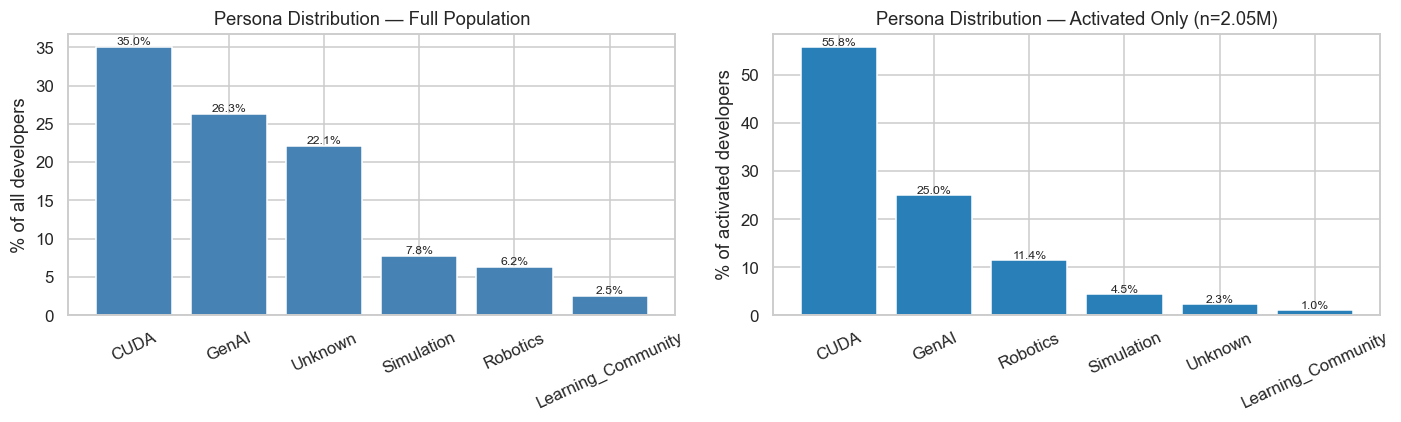

In [5]:
# Full population persona split
persona_dist = con.execute(f"""
    SELECT persona,
           COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct_all,
           ROUND(AVG(persona_confidence)*100, 1) AS avg_confidence_pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()
display(persona_dist)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(persona_dist['persona'], persona_dist['pct_all'], color='steelblue')
axes[0].set_ylabel('% of all developers')
axes[0].set_title('Persona Distribution — Full Population')
axes[0].tick_params(axis='x', rotation=25)
for i, row in persona_dist.iterrows():
    axes[0].text(i, row['pct_all'] + 0.3, f"{row['pct_all']:.1f}%", ha='center', fontsize=8)

# Activated-only persona split
persona_act = con.execute(f"""
    SELECT persona, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct
    FROM {T} WHERE is_activated = 1 GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()
axes[1].bar(persona_act['persona'], persona_act['pct'], color='#2980b9')
axes[1].set_ylabel('% of activated developers')
axes[1].set_title('Persona Distribution — Activated Only (n=2.05M)')
axes[1].tick_params(axis='x', rotation=25)
for i, row in persona_act.iterrows():
    axes[1].text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

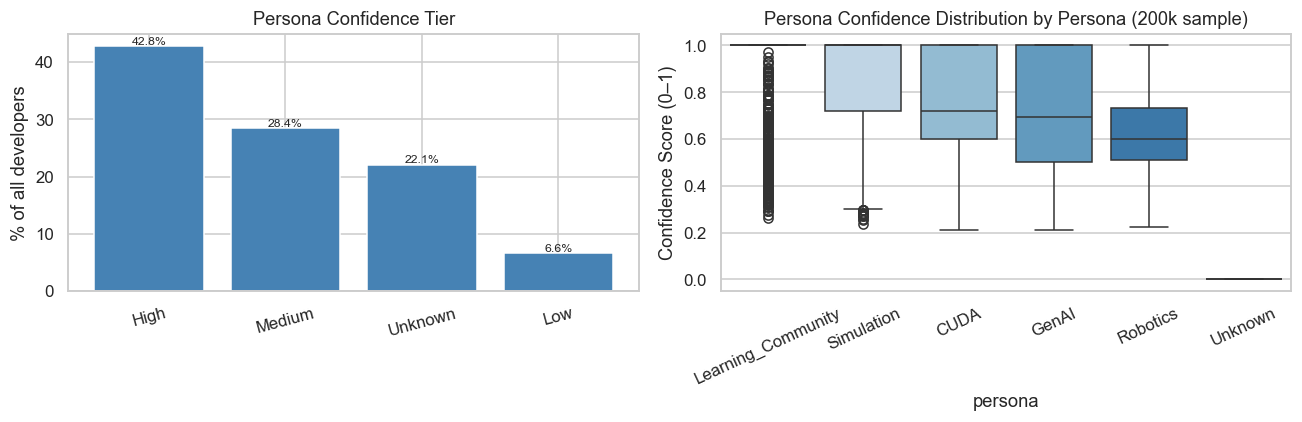

Mixed persona flag=1: 1,222,378 (13.0%) developers scored in multiple personas


In [6]:
# Persona confidence tier and mixed persona
conf_tier = con.execute(f"""
    SELECT persona_confidence_tier,
           COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()

mixed = con.execute(f"""
    SELECT mixed_persona_flag, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} GROUP BY 1
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(conf_tier['persona_confidence_tier'].astype(str), conf_tier['pct'], color='steelblue')
axes[0].set_title('Persona Confidence Tier')
axes[0].set_ylabel('% of all developers')
axes[0].tick_params(axis='x', rotation=15)
for i, row in conf_tier.iterrows():
    axes[0].text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%", ha='center', fontsize=8)

# Confidence distribution per persona (boxplot on 100k sample)
sample_conf = con.execute(f"""
    SELECT persona, persona_confidence
    FROM {T}
    USING SAMPLE 200000 ROWS
""").fetchdf()
persona_order = sample_conf.groupby('persona')['persona_confidence'].median().sort_values(ascending=False).index
sns.boxplot(data=sample_conf, x='persona', y='persona_confidence',
            order=persona_order, ax=axes[1], palette='Blues')
axes[1].set_title('Persona Confidence Distribution by Persona (200k sample)')
axes[1].set_ylabel('Confidence Score (0–1)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print(f"Mixed persona flag=1: {mixed[mixed['mixed_persona_flag']==1]['developers'].values[0]:,} ({mixed[mixed['mixed_persona_flag']==1]['pct'].values[0]:.1f}%) developers scored in multiple personas")

## 4. Activity Counts — Zero vs Non-Zero
Most developers have zero recent activity. We show the zero/non-zero split first, then the distribution within the non-zero group.

,window,pct_any_activity,n_nonzero
0,30d,4.60,428635
1,90d,8.30,779553
2,180d,13.20,1235074
3,lifetime activity count,81.70,7660278


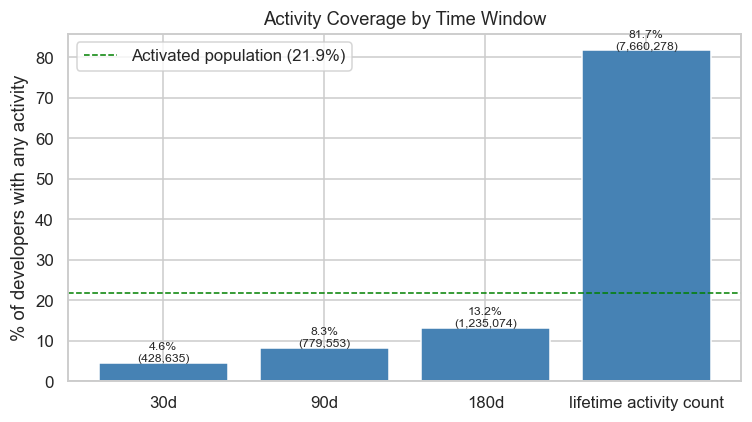

In [7]:
count_cols = ['activity_count_30d', 'activity_count_90d', 'activity_count_180d', 'lifetime_activity_count']

# % with any activity per window
any_activity = []
for col in count_cols:
    n_nonzero = con.execute(f'SELECT COUNT(*) FROM {T} WHERE {col} > 0').fetchone()[0]
    any_activity.append({'window': col.replace('activity_count_', '').replace('_', ' '),
                         'pct_any_activity': round(n_nonzero / total * 100, 1),
                         'n_nonzero': n_nonzero})
any_df = pd.DataFrame(any_activity)
display(any_df)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(any_df['window'], any_df['pct_any_activity'], color='steelblue')
ax.set_ylabel('% of developers with any activity')
ax.set_title('Activity Coverage by Time Window')
ax.axhline(n_activated/total*100, color='green', linestyle='--', linewidth=1, label=f'Activated population ({n_activated/total*100:.1f}%)')
ax.legend()
for bar, (_, row) in zip(bars, any_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['pct_any_activity']:.1f}%\n({row['n_nonzero']:,})", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

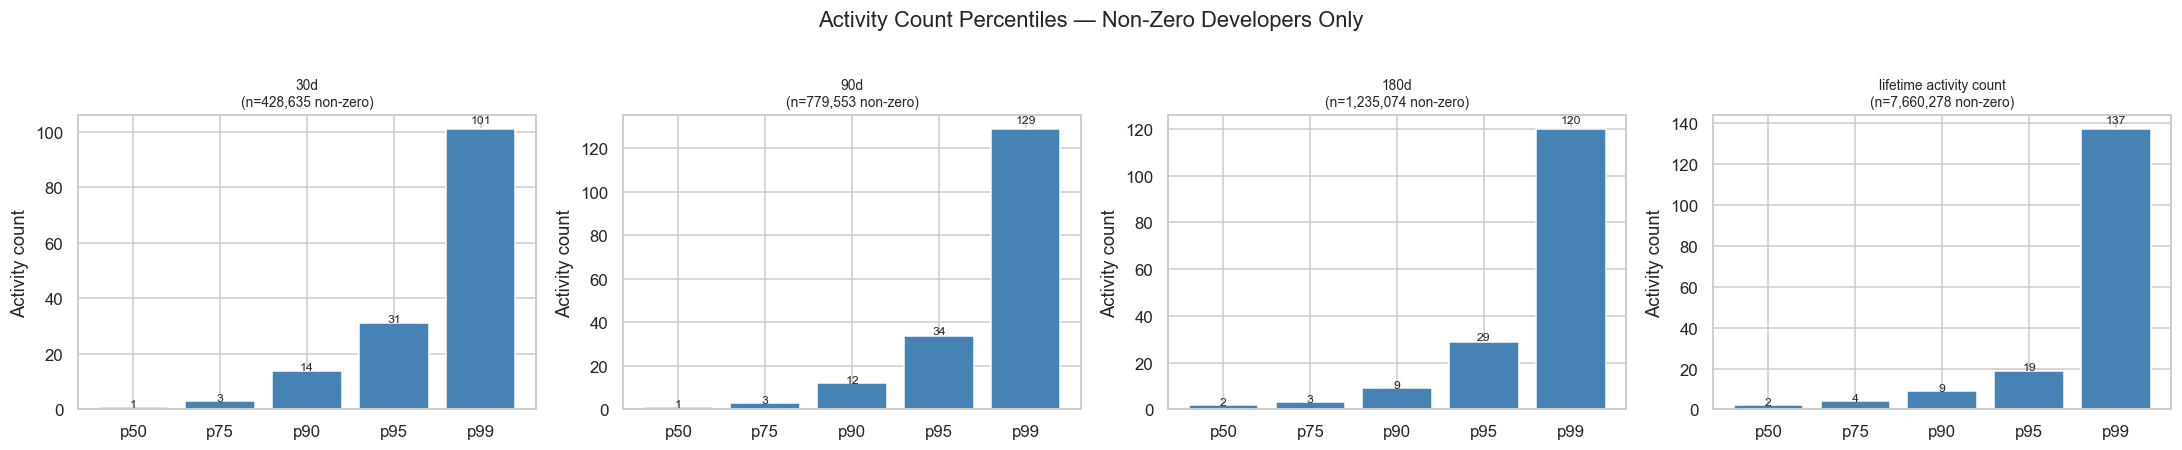

In [8]:
# Distribution of activity counts — NON-ZERO developers only
fig, axes = plt.subplots(1, len(count_cols), figsize=(5 * len(count_cols), 4), sharey=False)

for ax, col in zip(axes, count_cols):
    label = col.replace('activity_count_', '').replace('_', ' ')
    p50, p75, p90, p95, p99 = con.execute(f"""
        SELECT
            APPROX_QUANTILE({col}, 0.50),
            APPROX_QUANTILE({col}, 0.75),
            APPROX_QUANTILE({col}, 0.90),
            APPROX_QUANTILE({col}, 0.95),
            APPROX_QUANTILE({col}, 0.99)
        FROM {T} WHERE {col} > 0
    """).fetchone()
    pcts = [p50, p75, p90, p95, p99]
    labels = ['p50', 'p75', 'p90', 'p95', 'p99']
    ax.bar(labels, pcts, color='steelblue')
    n = con.execute(f'SELECT COUNT(*) FROM {T} WHERE {col} > 0').fetchone()[0]
    ax.set_title(f'{label}\n(n={n:,} non-zero)', fontsize=9)
    ax.set_ylabel('Activity count')
    for i, v in enumerate(pcts):
        ax.text(i, v * 1.02, f'{v:,.0f}', ha='center', fontsize=8)

plt.suptitle('Activity Count Percentiles — Non-Zero Developers Only', y=1.02)
plt.tight_layout()
plt.show()

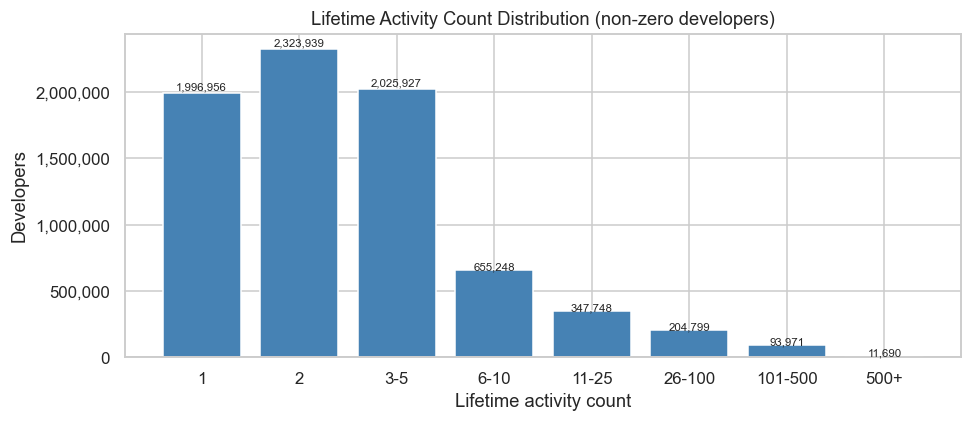

In [9]:
# Log-scale histogram for lifetime activity (most informative window)
bins = con.execute(f"""
    SELECT
        CASE
            WHEN lifetime_activity_count = 1   THEN '1'
            WHEN lifetime_activity_count <= 2  THEN '2'
            WHEN lifetime_activity_count <= 5  THEN '3-5'
            WHEN lifetime_activity_count <= 10 THEN '6-10'
            WHEN lifetime_activity_count <= 25 THEN '11-25'
            WHEN lifetime_activity_count <= 100 THEN '26-100'
            WHEN lifetime_activity_count <= 500 THEN '101-500'
            ELSE '500+'
        END AS bucket,
        MIN(lifetime_activity_count) AS sort_key,
        COUNT(*) AS developers
    FROM {T} WHERE lifetime_activity_count > 0
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bins['bucket'], bins['developers'], color='steelblue')
ax.set_xlabel('Lifetime activity count')
ax.set_ylabel('Developers')
ax.set_title('Lifetime Activity Count Distribution (non-zero developers)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (_, row) in enumerate(bins.iterrows()):
    ax.text(i, row['developers'] * 1.01, f'{row["developers"]:,}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

## 5. Binary Flags Summary

,flag,n_true,pct_true
0,is_activated,2052459,21.88
4,dormant_flag,1826053,19.46
1,mixed_persona_flag,1222378,13.03
2,recent_build_flag,131300,1.40
5,at_risk_flag,27911,0.30
3,recent_champion_flag,2085,0.02


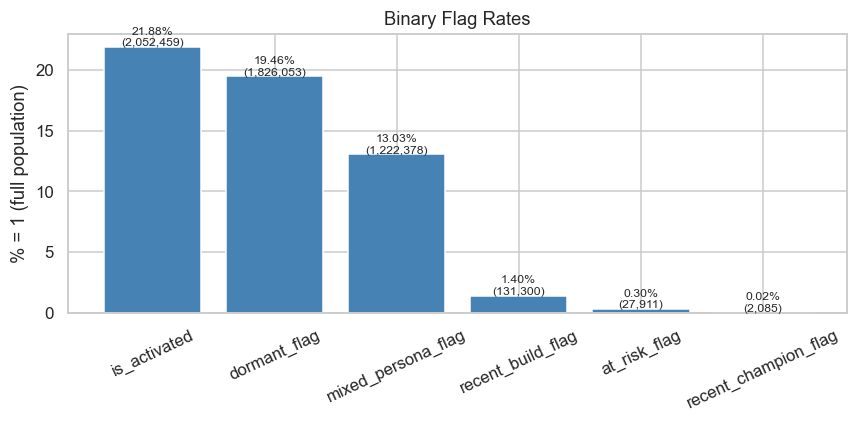

In [10]:
binary_cols = ['is_activated', 'mixed_persona_flag', 'recent_build_flag',
               'recent_champion_flag', 'dormant_flag', 'at_risk_flag']

flag_rows = []
for col in binary_cols:
    n1 = con.execute(f'SELECT SUM({col}) FROM {T}').fetchone()[0] or 0
    pct = n1 / total * 100
    flag_rows.append({'flag': col, 'n_true': int(n1), 'pct_true': round(pct, 2)})
flag_df = pd.DataFrame(flag_rows).sort_values('pct_true', ascending=False)
display(flag_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(flag_df['flag'], flag_df['pct_true'], color='steelblue')
ax.set_ylabel('% = 1 (full population)')
ax.set_title('Binary Flag Rates')
ax.tick_params(axis='x', rotation=25)
for bar, (_, row) in zip(bars, flag_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{row['pct_true']:.2f}%\n({row['n_true']:,})", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Lifetime Behavioral Features (Activated Developers)
`lifetime_build_count`, `lifetime_champion_count`, `lifetime_high_effort_count` — analyzed among activated developers only, since unactivated have 0 by definition.

In [11]:
behav_cols = ['lifetime_build_count', 'lifetime_champion_count',
              'lifetime_high_effort_count', 'lifetime_meaningful_weeks']

# % of activated developers with non-zero values
coverage_rows = []
for col in behav_cols:
    n_nonzero = con.execute(f'SELECT COUNT(*) FROM {T} WHERE is_activated=1 AND {col} > 0').fetchone()[0]
    pct = n_nonzero / n_activated * 100
    p50, p90, p99, mx = con.execute(f"""
        SELECT APPROX_QUANTILE({col},0.5), APPROX_QUANTILE({col},0.9),
               APPROX_QUANTILE({col},0.99), MAX({col})
        FROM {T} WHERE is_activated=1 AND {col} > 0
    """).fetchone()
    coverage_rows.append({'feature': col, 'pct_nonzero_activated': round(pct,1),
                          'p50': p50, 'p90': p90, 'p99': p99, 'max': mx})
display(pd.DataFrame(coverage_rows))

,feature,pct_nonzero_activated,p50,p90,p99,max
0,lifetime_build_count,22.90,2,29,354,2019379
1,lifetime_champion_count,51.00,1,2,10,35438
2,lifetime_high_effort_count,68.80,1,8,129,2019379
3,lifetime_meaningful_weeks,100.00,2,7,27,323


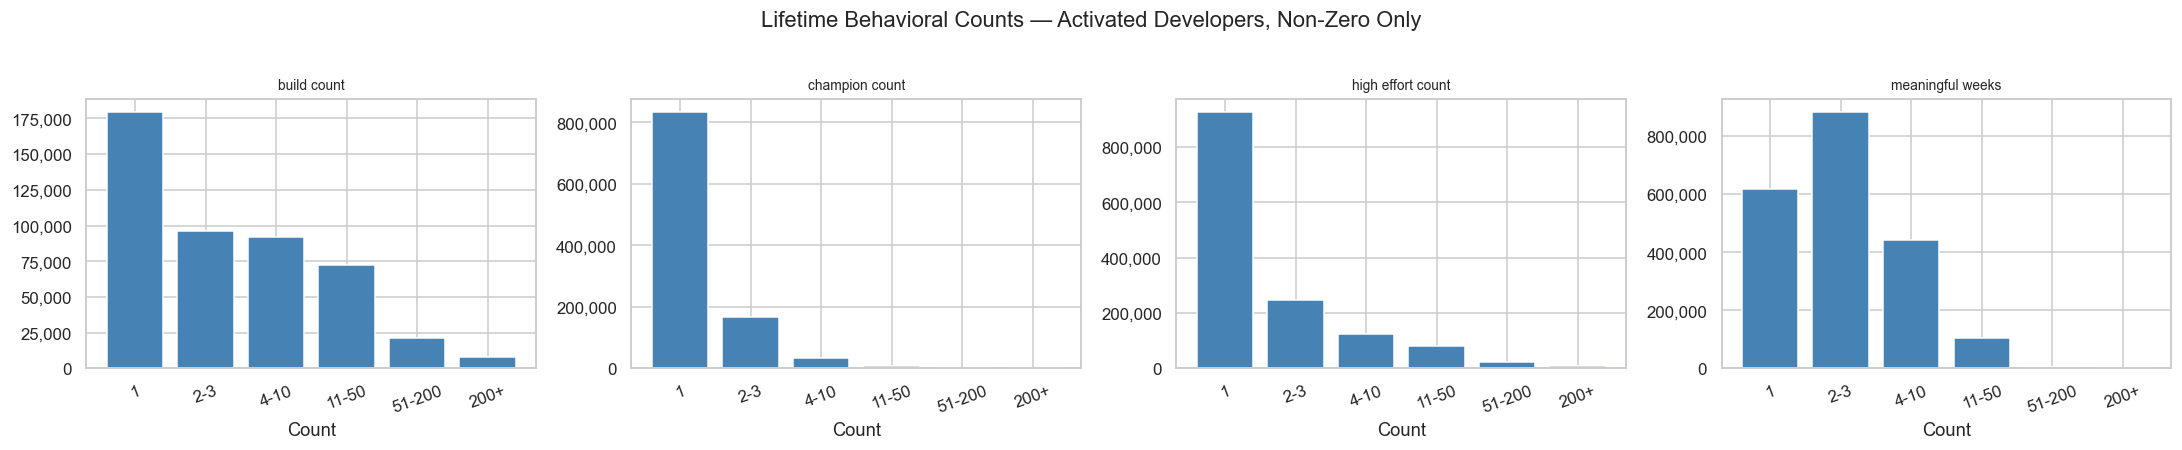

In [12]:
# Bucket histograms for behavioral features — activated, non-zero only
bucket_sql = """
    SELECT
        CASE
            WHEN {col} = 1    THEN '1'
            WHEN {col} <= 3   THEN '2-3'
            WHEN {col} <= 10  THEN '4-10'
            WHEN {col} <= 50  THEN '11-50'
            WHEN {col} <= 200 THEN '51-200'
            ELSE '200+'
        END AS bucket,
        MIN({col}) AS sort_key,
        COUNT(*) AS developers
    FROM {T} WHERE is_activated=1 AND {col} > 0
    GROUP BY 1 ORDER BY sort_key
"""

fig, axes = plt.subplots(1, len(behav_cols), figsize=(5*len(behav_cols), 4))
for ax, col in zip(axes, behav_cols):
    df = con.execute(bucket_sql.format(col=col, T=T)).fetchdf()
    if df.empty:
        ax.set_title(f'{col}\n(no data)')
        continue
    ax.bar(df['bucket'], df['developers'], color='steelblue')
    ax.set_title(col.replace('lifetime_','').replace('_',' '), fontsize=9)
    ax.set_xlabel('Count')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Lifetime Behavioral Counts — Activated Developers, Non-Zero Only', y=1.02)
plt.tight_layout()
plt.show()

## 7. Journey State Analysis

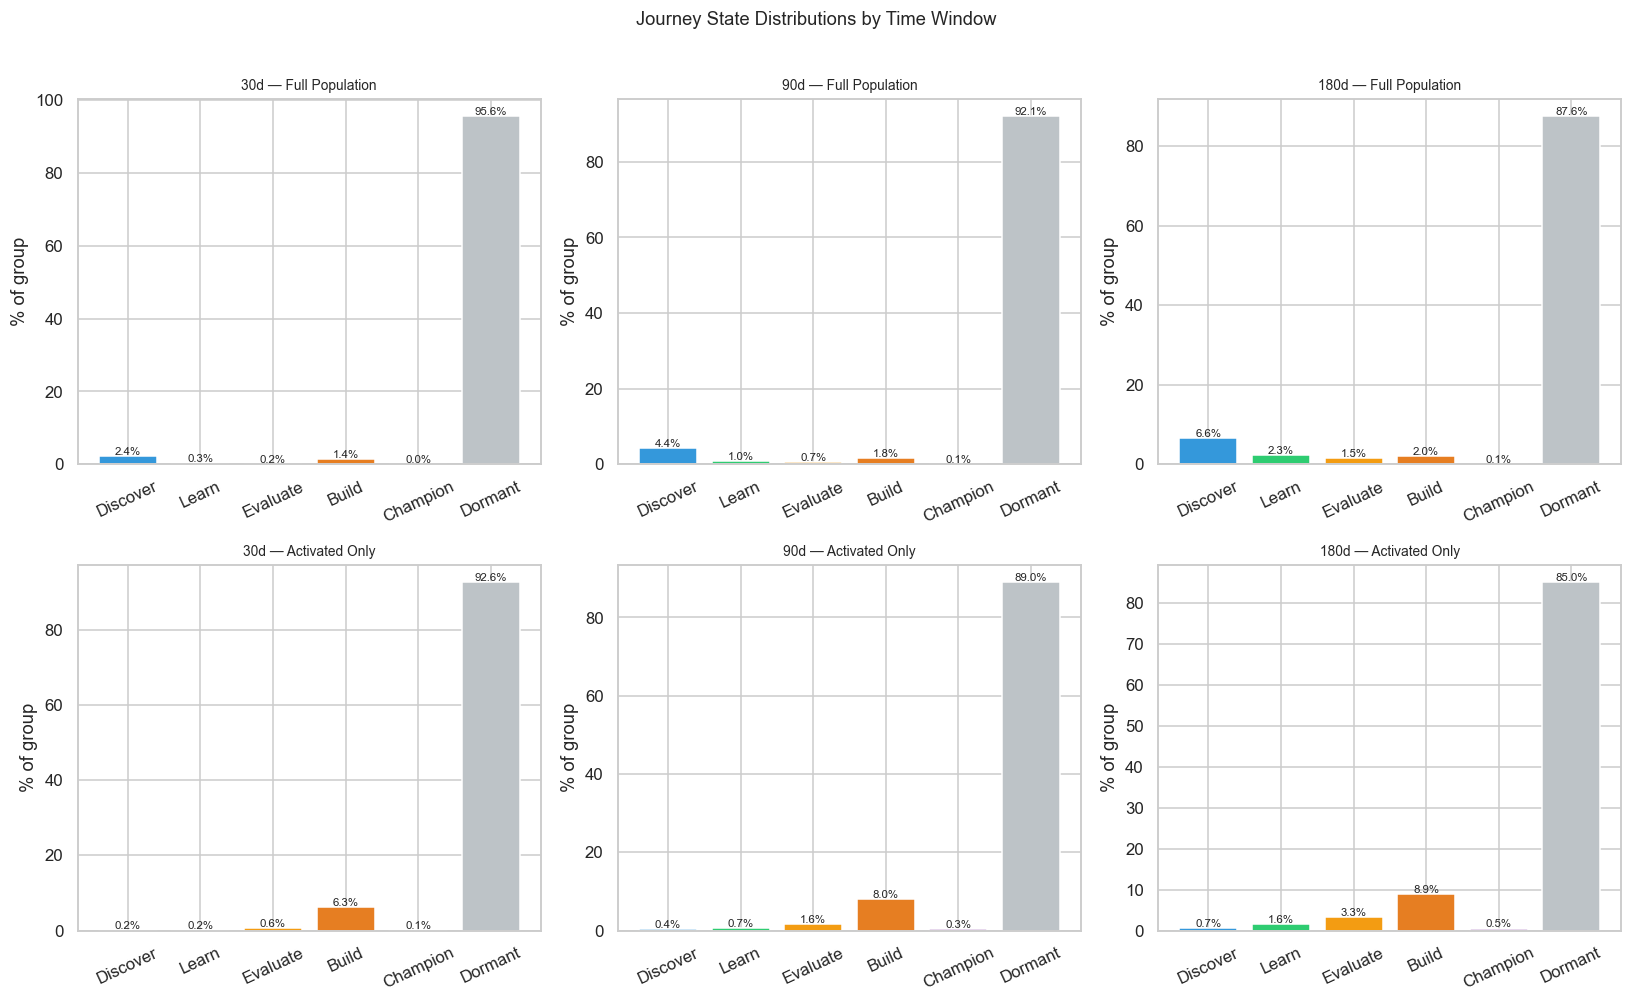

In [13]:
journey_cols = ['current_journey_state_30d', 'recent_journey_state_90d', 'historical_journey_state_180d']
state_order = ['Discover', 'Learn', 'Evaluate', 'Build', 'Champion', 'Dormant']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(journey_cols):
    label = col.replace('current_journey_state_','').replace('recent_journey_state_','').replace('historical_journey_state_','')

    for j, (pop_filter, pop_label, n_pop) in enumerate([
        ('1=1', 'Full Population', total),
        ('is_activated = 1', 'Activated Only', n_activated)
    ]):
        ax = axes[j][i]
        vc = con.execute(f"""
            SELECT {col} AS state, COUNT(*) AS developers,
                   ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
            FROM {T} WHERE {pop_filter}
            GROUP BY 1 ORDER BY 2 DESC
        """).fetchdf()
        # Sort by state order
        vc['sort'] = vc['state'].map({s: i for i, s in enumerate(state_order)}).fillna(99)
        vc = vc.sort_values('sort')
        state_colors = {'Discover':'#3498db','Learn':'#2ecc71','Evaluate':'#f39c12',
                        'Build':'#e67e22','Champion':'#9b59b6','Dormant':'#bdc3c7'}
        bar_colors = [state_colors.get(s, 'steelblue') for s in vc['state']]
        bars = ax.bar(vc['state'], vc['pct'], color=bar_colors)
        ax.set_title(f'{label} — {pop_label}', fontsize=9)
        ax.set_ylabel('% of group')
        ax.tick_params(axis='x', rotation=25)
        for bar, (_, row) in zip(bars, vc.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{row['pct']:.1f}%", ha='center', fontsize=7.5)

plt.suptitle('Journey State Distributions by Time Window', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

,value,developers,pct
0,Plateaued,8624449,91.93
1,Mixed / stable,429175,4.57
2,Newly dormant,327853,3.49
3,Fading,31,0.00


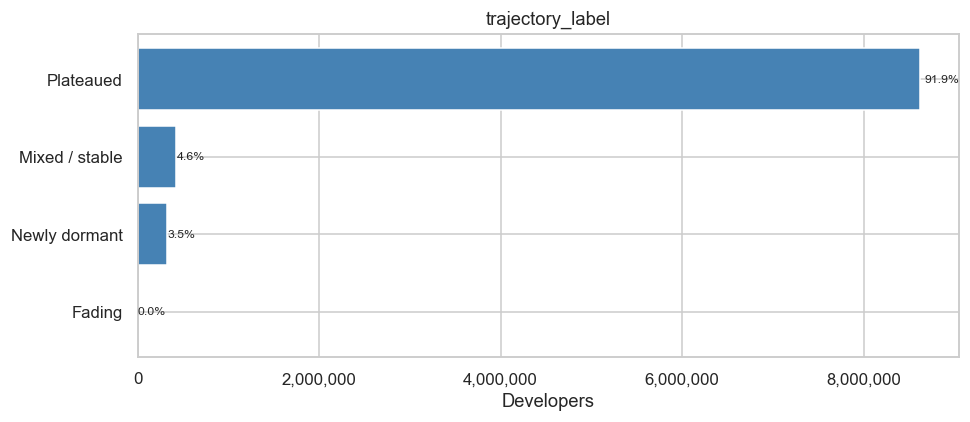

,value,developers,pct
0,Stable,9052152,96.49
1,Churned,327853,3.49
2,Regressed,1503,0.02


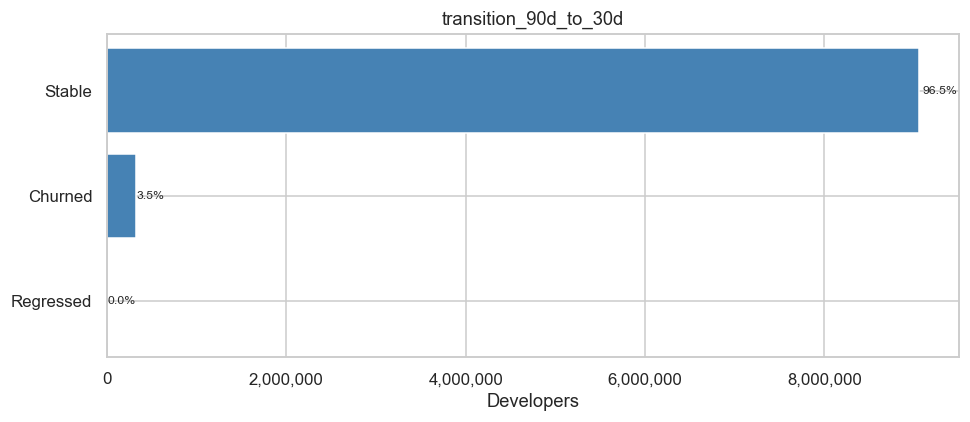

In [14]:
# Trajectory label and transition
for cat_col in ['trajectory_label', 'transition_90d_to_30d']:
    vc = con.execute(f"""
        SELECT {cat_col} AS value, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct
        FROM {T} GROUP BY 1 ORDER BY 2 DESC LIMIT 20
    """).fetchdf()
    display(vc)

    fig, ax = plt.subplots(figsize=(9, max(4, len(vc)*0.4)))
    ax.barh(vc['value'].astype(str)[::-1], vc['developers'][::-1], color='steelblue')
    ax.set_xlabel('Developers')
    ax.set_title(cat_col)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for i, (_, row) in enumerate(vc[::-1].iterrows()):
        ax.text(row['developers'] * 1.005, i, f"{row['pct']:.1f}%", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Dormancy Deep Dive (Activated Population)

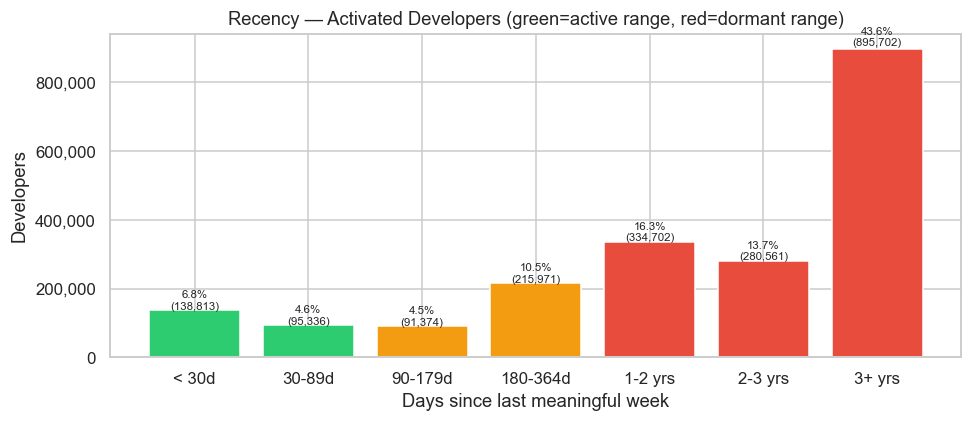

,bucket,developers,pct
0,< 30d,138813,6.80
1,30-89d,95336,4.60
2,90-179d,91374,4.50
3,180-364d,215971,10.50
4,1-2 yrs,334702,16.30
5,2-3 yrs,280561,13.70
6,3+ yrs,895702,43.60


In [15]:
# Days since last meaningful week — among activated developers only
days_data = con.execute(f"""
    SELECT
        CASE
            WHEN days_since_last_meaningful_week < 30   THEN '< 30d'
            WHEN days_since_last_meaningful_week < 90   THEN '30-89d'
            WHEN days_since_last_meaningful_week < 180  THEN '90-179d'
            WHEN days_since_last_meaningful_week < 365  THEN '180-364d'
            WHEN days_since_last_meaningful_week < 730  THEN '1-2 yrs'
            WHEN days_since_last_meaningful_week < 1095 THEN '2-3 yrs'
            ELSE '3+ yrs'
        END AS bucket,
        MIN(days_since_last_meaningful_week) AS sort_key,
        COUNT(*) AS developers,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T}
    WHERE is_activated = 1 AND days_since_last_meaningful_week IS NOT NULL
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors_days = ['#2ecc71','#2ecc71','#f39c12','#f39c12','#e74c3c','#e74c3c','#e74c3c']
bars = ax.bar(days_data['bucket'], days_data['developers'], color=bar_colors_days[:len(days_data)])
ax.set_ylabel('Developers')
ax.set_xlabel('Days since last meaningful week')
ax.set_title('Recency — Activated Developers (green=active range, red=dormant range)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, (_, row) in zip(bars, days_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{row['pct']:.1f}%\n({row['developers']:,})", ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

display(days_data[['bucket','developers','pct']])

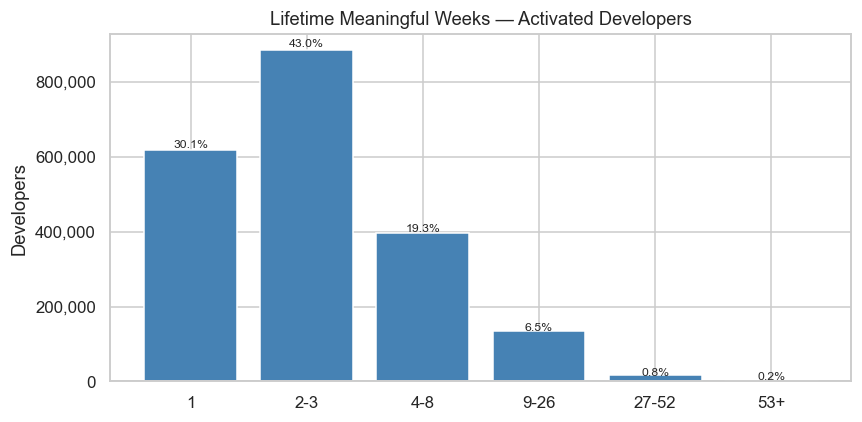

In [16]:
# Meaningful weeks — among activated developers
mw_data = con.execute(f"""
    SELECT
        CASE
            WHEN lifetime_meaningful_weeks = 1  THEN '1'
            WHEN lifetime_meaningful_weeks <= 3  THEN '2-3'
            WHEN lifetime_meaningful_weeks <= 8  THEN '4-8'
            WHEN lifetime_meaningful_weeks <= 26 THEN '9-26'
            WHEN lifetime_meaningful_weeks <= 52 THEN '27-52'
            ELSE '53+'
        END AS bucket,
        MIN(lifetime_meaningful_weeks) AS sort_key,
        COUNT(*) AS developers,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} WHERE is_activated = 1
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mw_data['bucket'], mw_data['developers'], color='steelblue')
ax.set_ylabel('Developers')
ax.set_title('Lifetime Meaningful Weeks — Activated Developers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (_, row) in enumerate(mw_data.iterrows()):
    ax.text(i, row['developers'] * 1.01, f"{row['pct']:.1f}%", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Time Window Feature Correlations (Log-Transformed, Activated Developers)

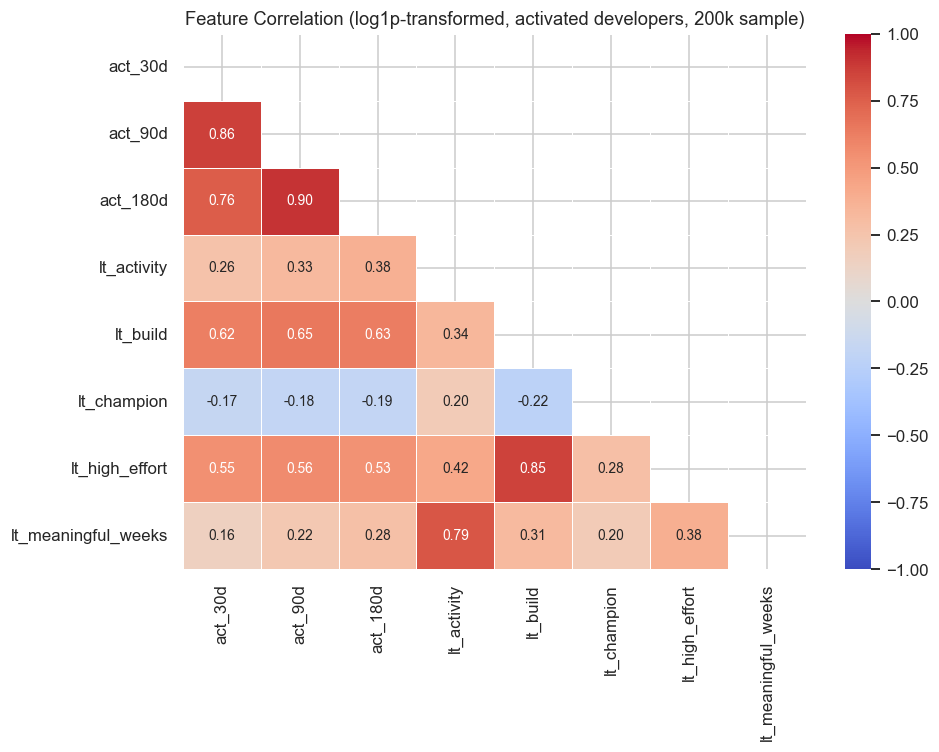

In [17]:
# Use log1p to handle zero-heavy, right-skewed counts
# Filter to activated developers to remove the massive zero block
window_cols = ['activity_count_30d', 'activity_count_90d', 'activity_count_180d',
               'lifetime_activity_count', 'lifetime_build_count',
               'lifetime_champion_count', 'lifetime_high_effort_count',
               'lifetime_meaningful_weeks']

sample = con.execute(f"""
    SELECT {', '.join(window_cols)}
    FROM {T}
    WHERE is_activated = 1
    USING SAMPLE 200000 ROWS
""").fetchdf()

log_sample = np.log1p(sample.fillna(0))
log_sample.columns = [c.replace('activity_count_','act_').replace('lifetime_','lt_').replace('_count','') for c in log_sample.columns]

corr = log_sample.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Feature Correlation (log1p-transformed, activated developers, 200k sample)')
plt.tight_layout()
plt.show()

## 10. Cross-Segment Breakdowns by Persona

,persona,total_developers,activation_rate_pct,median_lifetime_activity,median_meaningful_weeks,pct_mixed_persona
0,Robotics,586379,39.90,5,1.00,17.00
1,CUDA,3284784,34.90,3,1.00,8.60
2,GenAI,2466314,20.80,2,1.00,32.10
3,Simulation,730837,12.50,2,1.00,5.50
4,Learning_Community,235484,8.70,2,1.00,3.70
5,Unknown,2077710,2.30,0,0.00,0.00


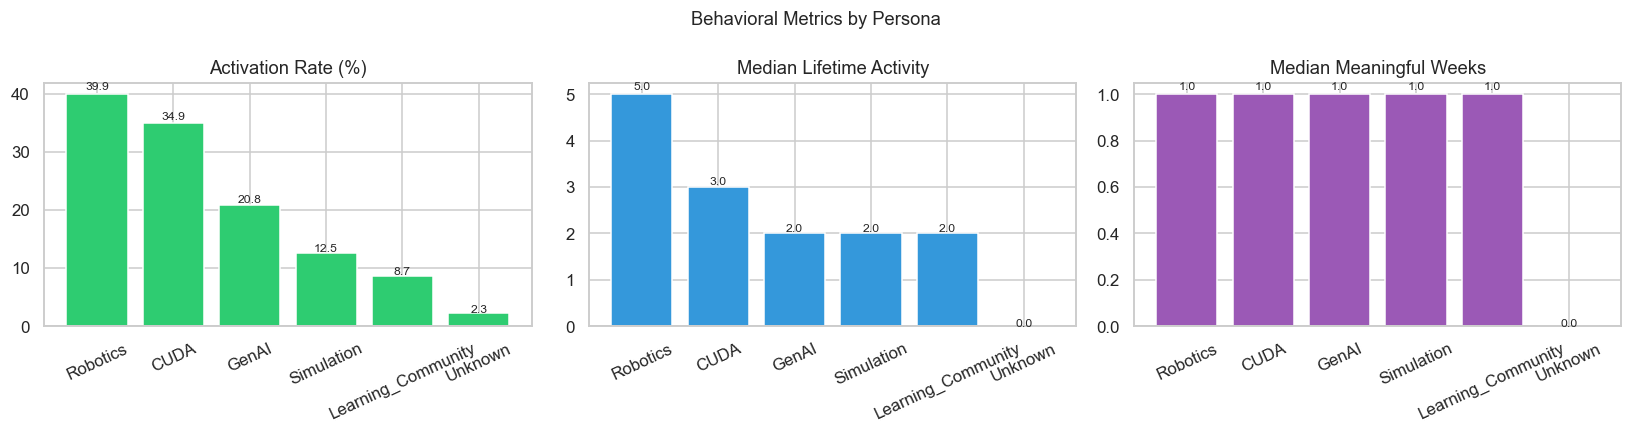

In [18]:
# Activation rate and behavioral medians by persona
persona_summary = con.execute(f"""
    SELECT
        persona,
        COUNT(*) AS total_developers,
        ROUND(AVG(is_activated)*100, 1) AS activation_rate_pct,
        APPROX_QUANTILE(lifetime_activity_count, 0.5) AS median_lifetime_activity,
        APPROX_QUANTILE(lifetime_meaningful_weeks, 0.5) AS median_meaningful_weeks,
        ROUND(AVG(mixed_persona_flag)*100, 1) AS pct_mixed_persona
    FROM {T}
    GROUP BY 1 ORDER BY activation_rate_pct DESC
""").fetchdf()
display(persona_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('activation_rate_pct', 'Activation Rate (%)', '#2ecc71'),
           ('median_lifetime_activity', 'Median Lifetime Activity', '#3498db'),
           ('median_meaningful_weeks', 'Median Meaningful Weeks', '#9b59b6')]

for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(persona_summary['persona'], persona_summary[col], color=color)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=25)
    for i, (_, row) in enumerate(persona_summary.iterrows()):
        ax.text(i, row[col] * 1.02, f"{row[col]:.1f}", ha='center', fontsize=8)

plt.suptitle('Behavioral Metrics by Persona', fontsize=12)
plt.tight_layout()
plt.show()

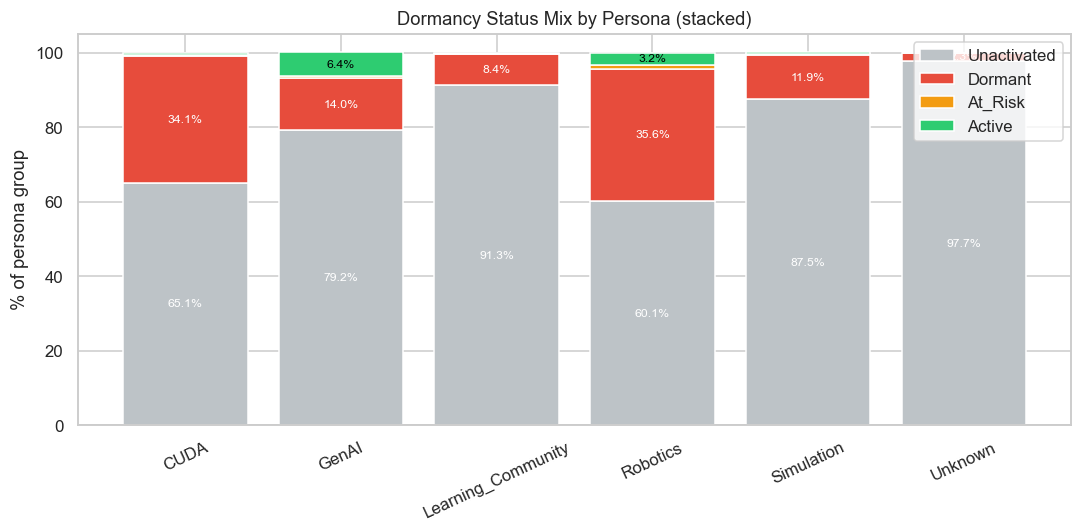

In [19]:
# Dormancy mix by persona
dorm_by_persona = con.execute(f"""
    SELECT persona, dormancy_status, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY persona), 1) AS pct
    FROM {T} GROUP BY 1, 2
""").fetchdf()

pivot = dorm_by_persona.pivot(index='persona', columns='dormancy_status', values='pct').fillna(0)
status_order = [c for c in ['Unactivated','Dormant','At_Risk','Active'] if c in pivot.columns]
pivot = pivot[status_order]

fig, ax = plt.subplots(figsize=(10, 5))
status_colors = {'Unactivated':'#bdc3c7','Dormant':'#e74c3c','At_Risk':'#f39c12','Active':'#2ecc71'}
bottom = np.zeros(len(pivot))
for status in status_order:
    vals = pivot[status].values
    ax.bar(pivot.index, vals, bottom=bottom, label=status, color=status_colors.get(status, 'gray'))
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 2:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white' if status in ['Dormant','Unactivated'] else 'black')
    bottom += vals

ax.set_ylabel('% of persona group')
ax.set_title('Dormancy Status Mix by Persona (stacked)')
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

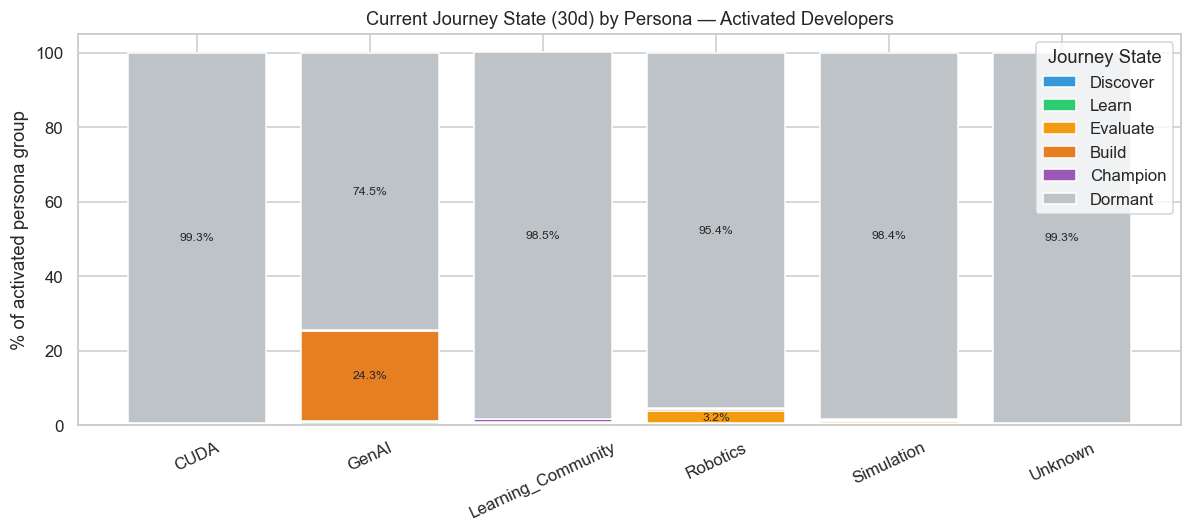

In [20]:
# Journey state by persona — activated developers only
journey_by_persona = con.execute(f"""
    SELECT persona, current_journey_state_30d AS journey_state,
           COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY persona), 1) AS pct
    FROM {T}
    WHERE is_activated = 1
    GROUP BY 1, 2
""").fetchdf()

pivot_j = journey_by_persona.pivot(index='persona', columns='journey_state', values='pct').fillna(0)
j_order = [c for c in state_order if c in pivot_j.columns]
pivot_j = pivot_j[j_order]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(pivot_j))
for state in j_order:
    vals = pivot_j[state].values
    ax.bar(pivot_j.index, vals, bottom=bottom, label=state,
           color=state_colors.get(state, 'steelblue'))
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8)
    bottom += vals

ax.set_ylabel('% of activated persona group')
ax.set_title('Current Journey State (30d) by Persona — Activated Developers')
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right', title='Journey State')
plt.tight_layout()
plt.show()

## 11. Unique Activity Breadth (Activated Developers)

,value,developers,pct
0,0,1893099,92.20
1,1,84029,4.10
2,2,73664,3.60
3,3,1461,0.10
4,4,181,0.00
5,5,23,0.00
6,6,2,0.00


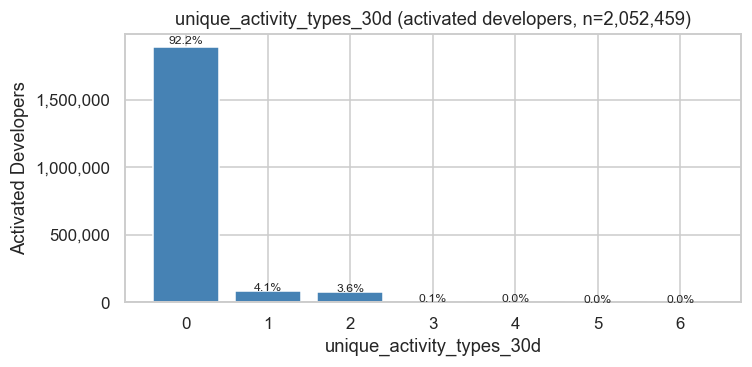

,value,developers,pct
0,0,1893099,92.20
1,1,84175,4.10
2,2,73562,3.60
3,3,1436,0.10
4,4,170,0.00
5,5,15,0.00
6,6,2,0.00


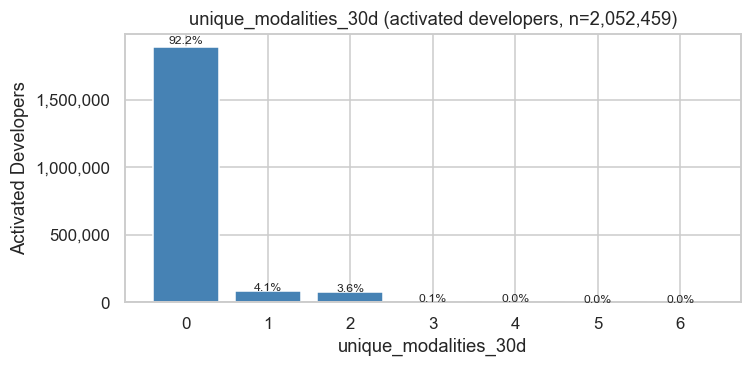

In [21]:
# unique_activity_types_30d and unique_modalities_30d among activated
for col in ['unique_activity_types_30d', 'unique_modalities_30d']:
    vc = con.execute(f"""
        SELECT {col} AS value, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
        FROM {T} WHERE is_activated = 1
        GROUP BY 1 ORDER BY 1
    """).fetchdf()
    display(vc)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(vc['value'].astype(str), vc['developers'], color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Activated Developers')
    ax.set_title(f'{col} (activated developers, n={n_activated:,})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for i, (_, row) in enumerate(vc.iterrows()):
        ax.text(i, row['developers'] * 1.01, f"{row['pct']:.1f}%", ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 12. Key Findings Summary

In [22]:
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print(f'\nTotal developers:     {total:>10,}')
print(f'Activated (21.9%):    {n_activated:>10,}')
print(f'Unactivated (78.1%):  {n_unactivated:>10,}')

print('\n--- Dormancy (full population) ---')
for _, row in dormancy.iterrows():
    print(f"  {row['dormancy_status']:<15} {row['developers']:>10,}  ({row['pct']:.1f}%)")

print('\n--- Activity coverage ---')
for _, row in any_df.iterrows():
    print(f"  {row['window']:<12}: {row['pct_any_activity']:.1f}% of all developers have any activity")

print('\n--- Persona mix (full population) ---')
for _, row in persona_dist.iterrows():
    print(f"  {row['persona']:<20} {row['developers']:>10,}  ({row['pct_all']:.1f}%)")

con.close()
print('\nConnection closed.')

KEY FINDINGS

Total developers:      9,381,508
Activated (21.9%):     2,052,459
Unactivated (78.1%):   7,329,049

--- Dormancy (full population) ---
  Unactivated      7,329,049  (78.1%)
  Dormant          1,826,053  (19.5%)
  Active             198,495  (2.1%)
  At_Risk             27,911  (0.3%)

--- Activity coverage ---
  30d         : 4.6% of all developers have any activity
  90d         : 8.3% of all developers have any activity
  180d        : 13.2% of all developers have any activity
  lifetime activity count: 81.7% of all developers have any activity

--- Persona mix (full population) ---
  CUDA                  3,284,784  (35.0%)
  GenAI                 2,466,314  (26.3%)
  Unknown               2,077,710  (22.1%)
  Simulation              730,837  (7.8%)
  Robotics                586,379  (6.2%)
  Learning_Community      235,484  (2.5%)

Connection closed.
